# Hierarchical Clustering - Theory & Mathematics: Agglomeration BY HAND

> **MLCourse · Machine Learning · unsupervised**

## What you'll learn
1. Build the pairwise Euclidean distance matrix for SIX real mall customers
2. Execute three manual **agglomerative merges** under SINGLE (min) linkage:
   find closest pair → merge → update distances → repeat
3. Draw the same six points' tree with `scipy.linkage` + `dendrogram` and
   read merge heights off it

> 💡 **Why by hand?** A dendrogram is just a LOG of merge decisions. Once you
  have made three of those decisions yourself - with a distance table you can
  verify by eye - scipy's `Z` matrix and its "height" axis stop being mysticism.

In [1]:
# ---- Setup cell -----------------------------------------------------------------
try:
    get_ipython().run_line_magic("matplotlib", "inline")   # inline rendering in Jupyter
except NameError:
    pass                                                   # plain-python fallback

import numpy as np                 # broadcasting-based distances
import pandas as pd                # pretty matrices
import matplotlib.pyplot as plt    # plotting the tree
import seaborn as sns              # styling

from scipy.cluster.hierarchy import linkage, dendrogram   # the real machinery

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
import urllib.request


def get_data(fname: str, url: str) -> Path:
    """Walk up to course root '02_machine_learning'; download-once data helper."""
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "02_machine_learning").is_dir():
            fpath = base / "02_machine_learning" / "data" / fname
            break
    else:
        raise RuntimeError("02_machine_learning folder not found above")
    if not fpath.exists():
        print(f"downloading {fname} ...")
        urllib.request.urlretrieve(url, fpath)
    return fpath

MALL_URL = ("https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/"
            "master/Machine%20Learning%20A-Z%20Template%20Folder/"
            "Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/"
            "Mall_Customers.csv")

## 1. Six real customers on the income × spend plane

We take customers #1-6 from Mall Customers so every number below can be
checked against the CSV by hand.

In [2]:
mall = pd.read_csv(get_data("mall_customers.csv", MALL_URL))
FEATURES = ["Annual Income (k$)", "Spending Score (1-100)"]
X6 = mall.loc[0:5, FEATURES].to_numpy(dtype=float)      # FIRST SIX rows only
ids = mall.loc[0:5, "CustomerID"].astype(str).tolist()  # labels like '0001'
pd.DataFrame(X6, index=[f"cust_{i}" for i in ids],
             columns=FEATURES).round(1)

,Annual Income (k$),Spending Score (1-100)
cust_1,15.0,39.0
cust_2,15.0,81.0
cust_3,16.0,6.0
cust_4,16.0,77.0
cust_5,17.0,40.0
cust_6,17.0,76.0


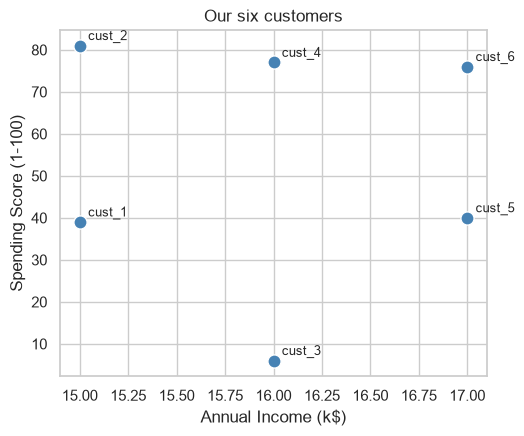

In [3]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))               # see WHO sits near WHOM
ax.scatter(X6[:, 0], X6[:, 1], s=90, color="steelblue", edgecolor="white")
for i, (x, y) in enumerate(X6):                          # annotate each point
    ax.annotate(f"cust_{ids[i]}", (x, y),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("Annual Income (k$)"); ax.set_ylabel("Spending Score (1-100)")
ax.set_title("Our six customers")
plt.show()

## 2. The pairwise distance matrix

Agglomerative clustering needs to know how far EVERY point is from EVERY
other point. With n points that is an n×n symmetric matrix with a zero
diagonal - the famous O(n²) memory cost that limits hierarchy on big data.

In [4]:
def pairwise_dist(A: np.ndarray) -> np.ndarray:
    """Euclidean distance matrix via broadcasting: add a row-axis vs col-axis."""
    return np.linalg.norm(A[:, None, :] - A[None, :, :], axis=2)

D = pairwise_dist(X6)
D_df = pd.DataFrame(D.round(1),                          # readable version for humans
                    index=[f"cust_{i}" for i in ids],
                    columns=[f"cust_{i}" for i in ids])
display(D_df)                                            # noqa: F821

,cust_1,cust_2,cust_3,cust_4,cust_5,cust_6
cust_1,0.0,42.0,33.0,38.0,2.2,37.1
cust_2,42.0,0.0,75.0,4.1,41.0,5.4
cust_3,33.0,75.0,0.0,71.0,34.0,70.0
cust_4,38.0,4.1,71.0,0.0,37.0,1.4
cust_5,2.2,41.0,34.0,37.0,0.0,36.0
cust_6,37.1,5.4,70.0,1.4,36.0,0.0


## 3. Manual agglomeration with SINGLE linkage

Single linkage defines cluster-to-cluster distance as the MINIMUM over all
cross pairs ("how close do they get?"). The loop:

| Step | Action |
|---|---|
| find | locate smallest OFF-DIAGONAL value in D |
| merge | union those two entries into one cluster |
| update | new distances = min(old d(a,·), old d(b,·)) per other cluster |

⚠️ We use single linkage because its update rule is trivially explainable;
ward's variance math is NOT pen-and-paper friendly (see module README).

In [5]:
clusters = {name: [name] for name in D_df.index}         # each customer alone
D_work = D_df.copy()                                     # working copy we mutate
merge_log = []                                           # (height, cluster_a, cluster_b)

for step in range(1, 4):                                 # exactly THREE manual merges
    # -- FIND: smallest OFF-DIAGONAL entry (without mutating the frame) --------
    arr = D_work.to_numpy(dtype=float)                   # numeric view of current state
    off_diag = np.where(np.eye(len(arr), dtype=bool),    # hide self-distances via a
                        np.inf, arr)                     # masked COPY, original untouched
    r, c = np.unravel_index(np.argmin(off_diag), arr.shape)
    a_name, b_name = D_work.index[r], D_work.columns[c]
    height = float(off_diag[r, c])
    merge_log.append((round(height, 2), a_name, b_name))

    # -- UPDATE: single-linkage = elementwise MIN of the two rows/cols ----------
    merged = D_work.loc[a_name].combine(
        D_work.loc[b_name], lambda x, y: min(x, y))      # min over the two members
    D_work.loc[a_name, :] = merged                       # write into row...
    D_work.loc[:, a_name] = merged                       # ...and column (symmetry)
    D_work = D_work.drop(index=b_name, columns=b_name)   # retire the absorbed twin

    clusters[a_name] = clusters.pop(a_name) + clusters.pop(b_name)  # bookkeeping
    print(f"\nstep {step}: MERGE {a_name} + {b_name} at height {height:.2f}")
    print(f"  clusters now: {[sorted(v) for v in clusters.values()]}")
    display(D_work.round(1))                             # noqa: F821 updated table

print("\nmerge log:", merge_log)


step 1: MERGE cust_4 + cust_6 at height 1.40
  clusters now: [['cust_1'], ['cust_2'], ['cust_3'], ['cust_5'], ['cust_4', 'cust_6']]


,cust_1,cust_2,cust_3,cust_4,cust_5
cust_1,0.0,42.0,33.0,37.1,2.2
cust_2,42.0,0.0,75.0,4.1,41.0
cust_3,33.0,75.0,0.0,70.0,34.0
cust_4,37.1,4.1,70.0,0.0,36.0
cust_5,2.2,41.0,34.0,36.0,0.0



step 2: MERGE cust_1 + cust_5 at height 2.20
  clusters now: [['cust_2'], ['cust_3'], ['cust_4', 'cust_6'], ['cust_1', 'cust_5']]


,cust_1,cust_2,cust_3,cust_4
cust_1,0.0,41.0,33.0,36.0
cust_2,41.0,0.0,75.0,4.1
cust_3,33.0,75.0,0.0,70.0
cust_4,36.0,4.1,70.0,0.0



step 3: MERGE cust_2 + cust_4 at height 4.10
  clusters now: [['cust_3'], ['cust_1', 'cust_5'], ['cust_2', 'cust_4', 'cust_6']]


,cust_1,cust_2,cust_3
cust_1,0.0,36.0,33.0
cust_2,36.0,0.0,70.0
cust_3,33.0,70.0,0.0



merge log: [(1.4, 'cust_4', 'cust_6'), (2.2, 'cust_1', 'cust_5'), (4.1, 'cust_2', 'cust_4')]


Read the log bottom-up: cust_0004+cust_0006 fused almost immediately (they
are ~1.4 units apart), then cust_0002 joined that pair at height ≈ 4.1
(single linkage = nearest member!), while cust_0003 stayed lonely longest.
Those heights ARE dendrogram branch lengths.

## 4. The same story from scipy - the dendrogram

`linkage(...)` returns an (n−1)×4 matrix: one row per merge -
`[cluster_id_a, cluster_id_b, merge_distance, member_count]`. Rows appear in
merge order, exactly like our log.

scipy merge table Z:


,id_a,id_b,distance,size
0,3.0,5.0,1.41,2.0
1,0.0,4.0,2.24,2.0
2,1.0,6.0,4.12,3.0
3,2.0,7.0,33.02,3.0
4,8.0,9.0,36.00,6.0


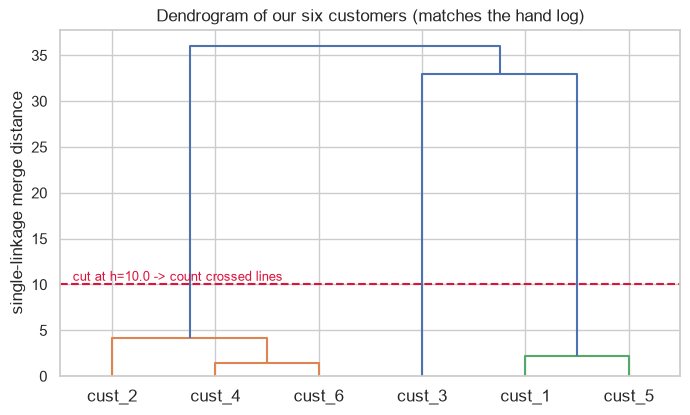

cutting at height 10.0 leaves 3 clusters


In [6]:
Z = linkage(X6, method="single")                         # SAME rule we used by hand
print("scipy merge table Z:")
display(pd.DataFrame(Z,                                  # noqa: F821
                     columns=["id_a", "id_b", "distance", "size"]).round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))                 # full tree: default
dendrogram(Z, labels=[f"cust_{i}" for i in ids],         # truncate_mode=None shows
           ax=ax)                                        # EVERY merge explicitly
ax.set_ylabel("single-linkage merge distance")
ax.set_title("Dendrogram of our six customers (matches the hand log)")
cut_h = 10.0                                             # example cut height
ax.axhline(cut_h, ls="--", color="crimson")              # horizontal slice
ax.text(0.02, cut_h + 0.4, f"cut at h={cut_h} -> count crossed lines",
        color="crimson", fontsize=9, transform=ax.get_yaxis_transform())
plt.show()

below = sum(1 for m in merge_log if m[0] <= cut_h)       # merges BELOW the slice
print(f"cutting at height {cut_h} leaves "
      f"{len(X6) - below} clusters")                     # n minus fusions below cut

## Summary

- Agglomerative clustering = repeatedly **find closest pair → merge → update
  distances**; the only design choice is the LINKAGE definition of "close".
- Single linkage's min-rule made cust_0002 join the 04/06 pair through its
  nearest neighbour - the chaining behaviour to watch out for on noisy data.
- The dendrogram simply PLOTS our merge log; cutting at height h yields
  however many branches cross that line.
- ⚠️ Production default is usually `ward` (variance-minimizing); compare
  linkages in the workflow notebook before trusting any single tree.